In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

In [2]:
bible_books = pd.Series(
    [
        "Genesis",
        "Exodus",
        "Leviticus",
        "Numbers",
        "Deuteronomy",
        "Joshua",
        "Judges",
        "Ruth",
        "1 Samuel",
        "2 Samuel",
        "1 Kings",
        "2 Kings",
        "1 Chronicles",
        "2 Chronicles",
        "Ezra",
        "Nehemiah",
        "Esther",
        "Job",
        "Psalms",
        "Proverbs",
        "Ecclesiastes",
        "Song of Solomon",
        "Isaiah",
        "Jeremiah",
        "Lamentations",
        "Ezekiel",
        "Daniel",
        "Hosea",
        "Joel",
        "Amos",
        "Obadiah",
        "Jonah",
        "Micah",
        "Nahum",
        "Habakkuk",
        "Zephaniah",
        "Haggai",
        "Zechariah",
        "Malachi",
        "Matthew",
        "Mark",
        "Luke",
        "John",
        "Acts",
        "Romans",
        "1 Corinthians",
        "2 Corinthians",
        "Galatians",
        "Ephesians",
        "Philippians",
        "Colossians",
        "1 Thessalonians",
        "2 Thessalonians",
        "1 Timothy",
        "2 Timothy",
        "Titus",
        "Philemon",
        "Hebrews",
        "James",
        "1 Peter",
        "2 Peter",
        "1 John",
        "2 John",
        "3 John",
        "Jude",
        "Revelation",
    ]
)
bible_books.index += 1
tisch = pd.read_pickle("./pickles/tisch.pickle")
sept = pd.read_pickle("./pickles/sept.pickle")

In [3]:
bible_books

1         Genesis
2          Exodus
3       Leviticus
4         Numbers
5     Deuteronomy
         ...     
62         1 John
63         2 John
64         3 John
65           Jude
66     Revelation
Length: 66, dtype: object

#### Munging

In [4]:
allusions = pd.read_pickle("./pickles/similarities.pickle")

In [15]:
tuples_df = tisch[["verse", "chapter", "book"]]
tuples_df["tuple"] = pd.Series(
    zip(bible_books.loc[tuples_df["book"]], tuples_df["chapter"], tuples_df["verse"])
)

nt_tuples = tuples_df["tuple"].unique()
nt_tuples

/tmp/ipykernel_29377/1109451937.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tuples_df["tuple"] = pd.Series(zip(bible_books.loc[tuples_df['book']], tuples_df['chapter'], tuples_df['verse']))


array([('Matthew', 1, 1), ('Matthew', 1, 2), ('Matthew', 1, 3), ...,
       ('Revelation', 22, 19), ('Revelation', 22, 20),
       ('Revelation', 22, 21)], dtype=object)

In [17]:
tuples_df = sept[["verse", "chapter", "book"]]
tuples_df["tuple"] = pd.Series(
    zip(bible_books.loc[tuples_df["book"]], tuples_df["chapter"], tuples_df["verse"])
)
ot_tuples = tuples_df["tuple"].unique()
ot_tuples

/tmp/ipykernel_29377/1476586529.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tuples_df["tuple"] = pd.Series(zip(bible_books.loc[tuples_df['book']], tuples_df['chapter'], tuples_df['verse']))


array([('Genesis', 1, 1), ('Genesis', 1, 2), ('Genesis', 1, 3), ...,
       ('Malachi', 4, 4), ('Malachi', 4, 5), ('Malachi', 4, 6)],
      dtype=object)

In [18]:
allusions = pd.DataFrame(data=allusions, index=ot_tuples, columns=nt_tuples)
allusions

,"(Matthew, 1, 1)","(Matthew, 1, 2)","(Matthew, 1, 3)","(Matthew, 1, 4)","(Matthew, 1, 5)","(Matthew, 1, 6)","(Matthew, 1, 7)","(Matthew, 1, 8)","(Matthew, 1, 9)","(Matthew, 1, 10)",...,"(Revelation, 22, 12)","(Revelation, 22, 13)","(Revelation, 22, 14)","(Revelation, 22, 15)","(Revelation, 22, 16)","(Revelation, 22, 17)","(Revelation, 22, 18)","(Revelation, 22, 19)","(Revelation, 22, 20)","(Revelation, 22, 21)"
"(Genesis, 1, 1)",21.554654,25.974077,25.805188,24.840617,25.830667,26.447814,24.874120,24.839121,24.834294,24.835359,...,25.043753,27.599766,27.315888,25.991416,25.137798,24.322503,25.123710,26.834301,23.507917,30.479649
"(Genesis, 1, 2)",15.149384,20.168797,19.645654,18.414695,19.720210,20.542760,18.470991,18.390079,18.392460,18.437734,...,19.170077,22.185425,21.460125,19.712993,19.325297,17.805504,19.337392,21.035215,17.369900,25.375321
"(Genesis, 1, 3)",18.260806,22.786878,22.514861,21.571750,22.592924,23.198812,21.609661,21.580802,21.576390,21.570839,...,21.788459,24.391708,24.176755,22.521237,22.073190,20.827991,22.119425,23.593251,20.466110,27.821241
"(Genesis, 1, 4)",16.525071,20.971446,20.672412,19.601267,20.810024,21.555410,19.632322,19.600669,19.602737,19.609807,...,20.193925,22.930740,22.485131,20.614276,20.348366,18.876839,20.377781,21.953764,18.401312,26.312663
"(Genesis, 1, 5)",18.070698,22.388839,22.340098,21.325167,22.479362,23.061583,21.364001,21.318288,21.322027,21.321857,...,21.464193,24.006728,23.735716,21.836896,21.700011,20.357290,21.714284,23.322864,19.841392,27.230565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(Malachi, 4, 2)",14.600050,19.693737,19.098305,17.864858,19.134581,20.008939,17.930257,17.816619,17.813284,17.870988,...,17.570282,21.711933,20.893449,19.173555,18.010353,17.240522,18.821842,20.497061,16.741026,25.041636
"(Malachi, 4, 3)",16.012591,21.024577,20.411164,19.122857,20.437663,21.406378,19.178747,19.059753,19.053486,19.127240,...,19.891692,23.193640,22.285856,20.556826,20.025973,18.617687,20.134091,21.920546,18.063700,26.153763
"(Malachi, 4, 4)",17.076498,22.067414,21.634050,20.617522,21.626823,22.390129,20.639378,20.610227,20.601498,20.621458,...,19.551722,23.538076,23.051247,21.393036,20.146830,19.605826,21.065527,22.671422,18.935586,26.803619
"(Malachi, 4, 5)",15.069952,20.108986,19.491008,18.230972,19.525016,20.378943,18.286204,18.196274,18.186873,18.245625,...,18.933900,22.234365,21.341139,19.670700,19.165529,17.613401,19.219324,20.926118,17.063509,25.428913


In [35]:
import matplotlib.pyplot as plt

/tmp/ipykernel_29377/3391605119.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ax.scatter(range(10), tisch.groupby(['book', 'chapter', 'verse']).apply(len).values[:10])


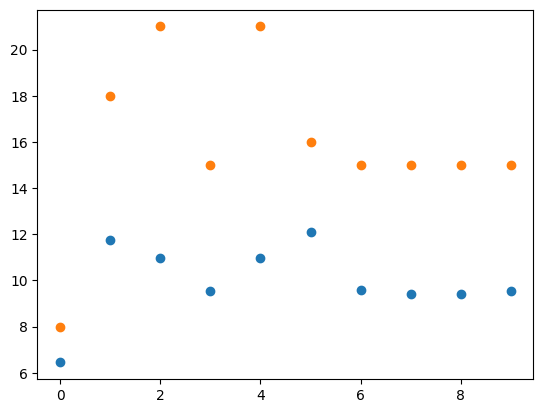

In [39]:
ax = plt.gca()
ax.scatter(range(10), allusions.min().values[:10])
ax.scatter(
    range(10), tisch.groupby(["book", "chapter", "verse"]).apply(len).values[:10]
)

In [27]:
bible_books[(bible_books == "Nehemiah")]

16    Nehemiah
dtype: object